# Assignment 04 - Notebook 03: Mạng nơ-ron tích chập 1D bằng TensorFlow/Keras và tổng hợp ba framework

**Học phần:** Phát triển các Hệ thống Thông minh
**Sinh viên:** Nguyễn Duy Nghĩa · **Mã sinh viên:** B23DCCN600 · **Lớp:** D23CTPM01
**Giảng viên:** PGS.TS Trần Đình Quế
**Học kỳ:** Học kỳ 1 năm học 2026 - 2027

## Mục tiêu của notebook

Notebook này có hai nhiệm vụ.

**Nhiệm vụ thứ nhất** là hiện thực đúng kiến trúc 1D CNN của hai notebook trước bằng
**TensorFlow 2.21.0 / Keras 3.15.1**, trên cùng phép chia dữ liệu, cùng seed và cùng siêu tham số.

**Nhiệm vụ thứ hai** là đóng vai trò **notebook tổng hợp** của toàn miền diabetes. Nó đọc ba file
`_partial_numpy.json`, `_partial_pytorch.json`, `_partial_tensorflow.json` do ba notebook sinh ra,
dựng ba hình so sánh ba bảng theo đúng danh mục ở Mục 6 của hợp đồng tích hợp, và ghi file
`metrics_diabetes.json` cuối cùng theo đúng lược đồ ở Mục 5.3.

## Điểm khác biệt về mặt kỹ thuật so với hai notebook trước

**Bố cục tensor.** Đây là khác biệt dễ gây lỗi nhất khi chuyển mô hình giữa hai framework. PyTorch
dùng **kênh trước** `(N, C, L)`, còn Keras dùng **kênh sau** `(N, L, C)`. Cùng một dữ liệu tám đặc
trưng một kênh sẽ có hình dạng `(N, 1, 8)` ở Notebook 01 và 02, nhưng phải là `(N, 8, 1)` ở đây.
Nếu nhầm, mô hình vẫn chạy trơn tru nhưng sẽ tích chập dọc trục kênh thay vì trục đặc trưng, cho
kết quả vô nghĩa mà không báo lỗi. Mục 4 sẽ kiểm tra rõ ràng điểm này.

**Mức trừu tượng.** Keras đóng gói toàn bộ vòng lặp huấn luyện vào một lời gọi `model.fit()`, bao
gồm chia lô, xáo trộn, đánh giá validation và gọi callback. Notebook 01 viết tay khoảng 25 dòng cho
cùng chức năng đó; Notebook 02 viết khoảng 15 dòng. Đây là thang đo cụ thể của việc trừu tượng hóa
tăng dần qua ba cách hiện thực, và Mục 9 sẽ bàn cái được cùng cái mất.

## 1. Nhập thư viện và cố định seed

In [1]:
import os, json, time
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # bớt log thông tin của TensorFlow

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix)
from IPython.display import Image, display

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
keras.utils.set_random_seed(RANDOM_SEED)

plt.rcParams["font.sans-serif"] = ["Segoe UI", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

DATA_PATH = "../data/diabetes_prediction_dataset.csv"
FIG_DIR, REP_DIR = "../reports/figures", "../reports"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(REP_DIR, exist_ok=True)

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("GPU khả dụng:", tf.config.list_physical_devices("GPU") or "không có, chạy trên CPU")

TensorFlow : 2.21.0
Keras      : 3.15.1


GPU khả dụng: không có, chạy trên CPU


## 2. Nạp và tiền xử lý dữ liệu

Phần này **giống hệt Notebook 01 và 02 đến từng dòng lệnh**, kể cả `random_state=42` trong cả hai
lần `train_test_split`. Nhờ đó ba notebook nhận đúng cùng 67 289 mẫu train, 14 419 mẫu validation
và 14 420 mẫu test. Khảo sát thăm dò chi tiết đã trình bày ở Notebook 01 nên không lặp lại.

### 2.1 Các bước tiền xử lý: làm gì và tại sao

Quy trình tiền xử lý tuân thủ nguyên văn hợp đồng tích hợp (`CONTRACT.md`, Mục 3) để năm miền dữ
liệu của Assignment 04 so sánh được với nhau. Mọi bước dưới đây giống hệt ba notebook, nhờ đó
chênh lệch chỉ số giữa ba framework phản ánh đúng khác biệt cài đặt chứ không phải khác biệt dữ liệu.

**Bước 1 - Khử trùng lặp.** Bộ dữ liệu thô chứa 3 854 bản ghi trùng lặp hoàn toàn. Nếu giữ lại,
cùng một bệnh nhân sẽ xuất hiện đồng thời ở tập huấn luyện và tập kiểm tra, làm chỉ số đánh giá
bị thổi phồng. Đây là dạng rò rỉ dữ liệu nghiêm trọng nên bắt buộc phải khử.

**Bước 2 - Loại `gender == 'Other'`.** Nhóm này chỉ có 18 mẫu, quá nhỏ để học được điều gì có ý
nghĩa thống kê, đồng thời ép ba nhãn danh định vào một trục số sẽ tạo quan hệ thứ tự giả.

**Bước 3 - Mã hóa `gender`** theo $\{\text{Male} \to 1,\ \text{Female} \to 0\}$. Sau khi loại
`Other`, biến chỉ còn hai mức nên mã hóa nhị phân là biểu diễn đầy đủ.

**Bước 4 - Mã hóa `smoking_history` thành ba mức theo cường độ phơi nhiễm:**

$$
\text{never},\ \text{No Info} \to 0; \qquad
\text{former},\ \text{not current} \to 1; \qquad
\text{current},\ \text{ever} \to 2
$$

Đây là mã hóa thứ bậc có cơ sở y học. Việc gộp `No Info` vào mức 0 là lựa chọn bảo thủ và chúng
tôi ghi nhận đây là giả định có thể tranh luận.

**Bước 5 - Chọn đúng tám đặc trưng theo đúng thứ tự hợp đồng quy định.**

**Bước 6 - Chia tập 70/15/15 có phân tầng** với `random_state=42`. Phân tầng giữ nguyên tỉ lệ lớp
dương trên cả ba tập. Tập validation dùng để chọn epoch tốt nhất, tập test không bao giờ tham gia
bất kỳ quyết định nào.

**Bước 7 - Chuẩn hóa `StandardScaler` fit trên train**, transform cho val và test:

$$ z_j = \frac{x_j - \mu_j^{\text{train}}}{\sigma_j^{\text{train}}} $$

Fit chỉ trên train là bắt buộc, nếu tính $\mu, \sigma$ trên toàn bộ dữ liệu thì thống kê của tập
test đã rò rỉ vào huấn luyện.

In [2]:
FEATURES = ["gender", "age", "hypertension", "heart_disease",
            "smoking_history", "bmi", "HbA1c_level", "blood_glucose_level"]

df_raw = pd.read_csv(DATA_PATH)
N_RAW = len(df_raw)

df = df_raw.drop_duplicates().copy()
df = df[df["gender"] != "Other"].copy()
df["gender"] = df["gender"].map({"Male": 1, "Female": 0})
df["smoking_history"] = df["smoking_history"].map({
    "never": 0, "No Info": 0, "former": 1, "not current": 1, "current": 2, "ever": 2})
assert df[FEATURES].isna().sum().sum() == 0, "Con gia tri thieu sau khi ma hoa"

X_all = df[FEATURES].values.astype(np.float64)
y_all = df["diabetes"].values.astype(np.float64)
N_CLEAN = len(X_all)

X_tr_raw, X_tmp, y_tr, y_tmp = train_test_split(
    X_all, y_all, test_size=0.30, stratify=y_all, random_state=RANDOM_SEED)
X_va_raw, X_te_raw, y_va, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_SEED)

scaler = StandardScaler().fit(X_tr_raw)
X_tr = scaler.transform(X_tr_raw).astype(np.float32)
X_va = scaler.transform(X_va_raw).astype(np.float32)
X_te = scaler.transform(X_te_raw).astype(np.float32)
N_TRAIN, N_VAL, N_TEST = len(X_tr), len(X_va), len(X_te)

print(f"Thô -> sạch : {N_RAW:,} -> {N_CLEAN:,} mẫu (loại {N_RAW - N_CLEAN:,})")
print(f"{'Tập':<12}{'Số mẫu':>10}{'Lớp dương':>12}{'Tỉ lệ dương':>14}")
for name, yy in [("train", y_tr), ("validation", y_va), ("test", y_te)]:
    print(f"{name:<12}{len(yy):>10,}{int(yy.sum()):>12,}{yy.mean():>14.4%}")
print()
print("Trung bình sau chuẩn hóa (train):", np.round(X_tr.mean(0), 6))
print("Độ lệch chuẩn sau chuẩn hóa      :", np.round(X_tr.std(0), 6))

Thô -> sạch : 100,000 -> 96,128 mẫu (loại 3,872)
Tập             Số mẫu   Lớp dương   Tỉ lệ dương
train           67,289       5,937       8.8231%
validation      14,419       1,272       8.8217%
test            14,420       1,273       8.8280%

Trung bình sau chuẩn hóa (train): [ 0.e+00 -0.e+00  2.e-06  1.e-06 -1.e-06 -0.e+00  0.e+00  0.e+00]
Độ lệch chuẩn sau chuẩn hóa      : [0.999704 1.000006 0.999763 1.000142 0.999731 0.99999  1.00001  0.999947]


### 2.2 Nhận xét tiền xử lý

Từ 100 000 dòng thô còn lại **96 128 mẫu sạch**, tỉ lệ lớp dương **8,8236%**. Khử trùng lặp làm
tỉ lệ dương tăng nhẹ từ 8,50% lên 8,82%, cho thấy các bản ghi trùng lặp lệch về lớp âm. Chia phân
tầng cho **67 289 mẫu train, 14 419 mẫu validation, 14 420 mẫu test**, tỉ lệ lớp dương giữ ở
8,82% trên cả ba tập (8,8231% / 8,8217% / 8,8280%), chênh lệch lớn nhất chỉ 0,0063 điểm phần trăm,
xác nhận phân tầng hoạt động đúng.

Sau chuẩn hóa, trung bình mọi đặc trưng trên train xấp xỉ $0$ và độ lệch chuẩn xấp xỉ $1$ với sai
số cỡ $3 \times 10^{-4}$. Sai số này không phải lỗi: chúng tôi ép ma trận đặc trưng về `float32`
sau khi chuẩn hóa để ba framework dùng chung một biểu diễn số, và `float32` chỉ giữ được khoảng
bảy chữ số thập phân có nghĩa. Mức sai lệch này hoàn toàn không ảnh hưởng tới huấn luyện.

## 3. Kiến trúc mạng và lý do chọn

Hợp đồng tích hợp quy định kiến trúc thống nhất cho dữ liệu bảng. Tám đặc trưng được coi như một
chuỗi một chiều dài $L = 8$ với $C_{\text{in}} = 1$ kênh:

```
đầu vào (1, 8)
  -> Conv1D(16 bộ lọc, K=3, padding='same')  -> ReLU
  -> Conv1D(16 bộ lọc, K=3, padding='same')  -> ReLU
  -> MaxPool1D(2)
  -> Flatten  (16 x 4 = 64)
  -> Dense(8) -> ReLU
  -> Dense(1) -> Sigmoid
```

Bảng đếm tham số:

| Tầng | Công thức | Số tham số |
|---|---|---|
| Conv1D-1 | $C_{\text{out}} \cdot C_{\text{in}} \cdot K + C_{\text{out}} = 16 \cdot 1 \cdot 3 + 16$ | 64 |
| Conv1D-2 | $16 \cdot 16 \cdot 3 + 16$ | 784 |
| Dense-1 | $64 \cdot 8 + 8$ | 520 |
| Dense-2 | $8 \cdot 1 + 1$ | 9 |
| **Tổng** | | **1 377** |

Mô hình chỉ có 1 377 tham số cho 67 289 mẫu huấn luyện, tức tỉ lệ mẫu trên tham số xấp xỉ 48,9:1.
Đây là chế độ **thiếu tham số** (under-parameterised), nên rủi ro quá khớp rất thấp và ta không
cần dropout hay điều chuẩn. Điều này cũng có nghĩa mọi chênh lệch giữa ba framework sẽ chủ yếu
đến từ khởi tạo ngẫu nhiên và thứ tự cộng dồn dấu phẩy động, chứ không phải từ dung lượng mô hình.

Đầu ra dùng **Sigmoid kết hợp Binary Cross-Entropy** vì đây là bài toán phân loại nhị phân.
Tối ưu bằng **Adam** với $\eta = 10^{-3}$, kích thước batch 256, huấn luyện 20 epoch. Epoch tốt
nhất được chọn theo **val loss nhỏ nhất**, và trọng số tại epoch đó được khôi phục trước khi đánh
giá trên tập test.

## 4. Chuẩn bị tensor theo bố cục kênh sau

Keras mặc định `data_format='channels_last'`, nên đầu vào của `Conv1D` phải có hình dạng
$(N, L, C_{\text{in}})$ chứ không phải $(N, C_{\text{in}}, L)$ như PyTorch. Với bài toán này:

$$
\underbrace{(N,\ 1,\ 8)}_{\text{Notebook 01 và 02}}
\qquad \longleftrightarrow \qquad
\underbrace{(N,\ 8,\ 1)}_{\text{Notebook 03}}
$$

Đây không phải chi tiết hình thức. Nếu vô ý đưa tensor `(N, 1, 8)` vào `Conv1D` của Keras, thư viện
sẽ hiểu là **một chuỗi dài 1 với 8 kênh**, rồi tích chập dọc trục dài 1. Mô hình vẫn biên dịch,
vẫn chạy, vẫn giảm loss, nhưng cửa sổ tích chập không hề trượt qua các đặc trưng nữa. Đây là loại
lỗi im lặng nguy hiểm nhất khi chuyển mô hình giữa hai framework, nên chúng tôi khẳng định hình
dạng bằng `assert` thay vì tin vào việc code chạy được.

In [3]:
X_tr_k = X_tr[:, :, None].astype(np.float32)      # (N, 8, 1) = (batch, chiều dài, kênh)
X_va_k = X_va[:, :, None].astype(np.float32)
X_te_k = X_te[:, :, None].astype(np.float32)
y_tr_k = y_tr.astype(np.float32)[:, None]
y_va_k = y_va.astype(np.float32)[:, None]
y_te_k = y_te.astype(np.float32)[:, None]

print("Bố cục kênh sau của Keras :", X_tr_k.shape, "= (batch, chiều dài L=8, kênh C=1)")
print("Bố cục kênh trước (NB 01/02):", X_tr[:, None, :].shape, "= (batch, kênh C=1, chiều dài L=8)")
assert X_tr_k.shape[1:] == (8, 1), "Sai bố cục tensor cho Keras"

# Kiểm chứng hai bố cục chứa đúng cùng dữ liệu, chỉ khác cách sắp trục
assert np.array_equal(X_tr_k[:, :, 0], X_tr), "Dữ liệu bị biến dạng khi đổi bố cục"
print("\nMẫu đầu tiên, bố cục kênh sau (8 bước, mỗi bước 1 kênh):")
print(X_tr_k[0].ravel().round(4))
print("Đúng bằng hàng đặc trưng gốc          :")
print(X_tr[0].round(4))

Bố cục kênh sau của Keras : (67289, 8, 1) = (batch, chiều dài L=8, kênh C=1)
Bố cục kênh trước (NB 01/02): (67289, 1, 8) = (batch, kênh C=1, chiều dài L=8)

Mẫu đầu tiên, bố cục kênh sau (8 bước, mỗi bước 1 kênh):
[-0.8419  0.8119 -0.289  -0.2045 -0.6043  0.5571  0.2486 -0.9345]
Đúng bằng hàng đặc trưng gốc          :
[-0.8419  0.8119 -0.289  -0.2045 -0.6043  0.5571  0.2486 -0.9345]


## 5. Hiện thực mô hình bằng Keras

### 5.1 Ánh xạ sang API của Keras

| Notebook 01 (NumPy) | Keras | Ghi chú |
|---|---|---|
| `Conv1D(1, 16, 3, 'same')` | `layers.Conv1D(16, 3, padding='same')` | Keras suy ra số kênh vào từ hình dạng đầu vào |
| `ReLU()` | `activation='relu'` | gộp luôn vào tầng tích chập |
| `MaxPool1D(2)` | `layers.MaxPooling1D(2)` | bước nhảy mặc định bằng cỡ cửa sổ |
| `Flatten()` | `layers.Flatten()` | giữ chiều batch |
| `Dense(64, 8)` | `layers.Dense(8)` | Keras suy ra $n_{\text{in}}$ khi xây |
| `Sigmoid()` + `bce_loss` | `BinaryCrossentropy(from_logits=True)` | dạng ổn định số, giống `BCEWithLogitsLoss` |
| `Adam(lr=1e-3)` | `keras.optimizers.Adam(1e-3)` | cùng $\beta_1, \beta_2, \epsilon$ mặc định |

Chúng tôi cho tầng cuối xuất **logit** thay vì xác suất, rồi dùng
`BinaryCrossentropy(from_logits=True)`, đúng như Notebook 02. Lý do đã giải thích ở đó: dạng ghép
ổn định số hơn hẳn vì không bao giờ tính $\log(0)$. Hệ quả cần nhớ khi đánh giá: ngưỡng $0{,}5$
trên xác suất tương đương ngưỡng $0$ trên logit, vì $\sigma(z) \ge 0{,}5 \iff z \ge 0$. Vì vậy
chỉ số accuracy phải khai báo `BinaryAccuracy(threshold=0.0)` chứ không phải mặc định $0{,}5$;
nếu quên, accuracy in ra trong log sẽ sai.

**Về khởi tạo trọng số.** Keras mặc định dùng Glorot Uniform, khác cả He Normal của Notebook 01
lẫn Kaiming Uniform của Notebook 02. Chúng tôi **giữ nguyên mặc định của mỗi framework** thay vì
ép chúng giống nhau, vì mục tiêu là so sánh ba cách hiện thực như người dùng thực sự viết chúng.
Mục 9 sẽ phân tích phần chênh lệch kết quả đến từ đâu.

In [4]:
def build_keras_model():
    keras.utils.set_random_seed(RANDOM_SEED)
    model = keras.Sequential([
        keras.Input(shape=(8, 1), name="dac_trung"),
        keras.layers.Conv1D(16, 3, padding="same", activation="relu", name="conv1"),
        keras.layers.Conv1D(16, 3, padding="same", activation="relu", name="conv2"),
        keras.layers.MaxPooling1D(2, name="maxpool"),
        keras.layers.Flatten(name="flatten"),
        keras.layers.Dense(8, activation="relu", name="dense1"),
        keras.layers.Dense(1, name="logit"),        # xuất logit, chưa qua sigmoid
    ], name="DiabetesCNN1D_Keras")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.BinaryCrossentropy(from_logits=True),
        metrics=[keras.metrics.BinaryAccuracy(name="acc", threshold=0.0)],
    )
    return model


model = build_keras_model()
model.summary()
N_PARAMS = int(sum(np.prod(w.shape) for w in model.trainable_weights))
print()
print(f"Tổng số tham số huấn luyện được: {N_PARAMS:,}")
assert N_PARAMS == 1377, f"Số tham số {N_PARAMS} khác 1377 như hợp đồng quy định"
print("Khớp chính xác với cài đặt NumPy (Notebook 01) và PyTorch (Notebook 02): 1 377.")

Model: "DiabetesCNN1D_Keras"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv1D)                  │ (None, 8, 16)          │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 8, 16)          │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool (MaxPooling1D)          │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 8)              │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logit (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,377 (5.38 KB)

 Trainable params: 1,377 (5.38 KB)

 Non-trainable params: 0 (0.00 B)


Tổng số tham số huấn luyện được: 1,377
Khớp chính xác với cài đặt NumPy (Notebook 01) và PyTorch (Notebook 02): 1 377.


**Diễn giải bảng tóm tắt mô hình.** Ba điểm đáng đọc kỹ.

Thứ nhất, **tổng số tham số là 1 377**, khớp chính xác với cả hai cài đặt trước. Đây là phép kiểm
định chéo có giá trị: ba framework với ba API hoàn toàn khác nhau cùng dựng ra một mô hình có đúng
cùng dung lượng, nên nếu có chênh lệch kết quả về sau thì chắc chắn không phải do khác kiến trúc.

Thứ hai, **hình dạng đầu ra từng tầng xác nhận bố cục kênh sau hoạt động đúng**: `conv1` cho
`(None, 8, 16)`, tức giữ nguyên chiều dài 8 nhờ `padding='same'` và nâng số kênh lên 16. Nếu bố
cục bị nhầm, chiều dài ở đây đã là 1 chứ không phải 8.

Thứ ba, `maxpool` đưa `(None, 8, 16)` xuống `(None, 4, 16)`, rồi `flatten` cho vector 64 chiều,
đúng bằng $16 \times 4$ mà Mục 3 đã tính. Chuỗi biến đổi hình dạng này khớp từng bước với cài đặt
NumPy ở Notebook 01.

## 6. Huấn luyện

Toàn bộ vòng lặp huấn luyện gói trong một lời gọi `model.fit()` với 20 epoch, batch 256,
`shuffle=True`. Chúng tôi dùng hai callback tự viết:

- `BestWeightsCallback`: theo dõi `val_loss` sau mỗi epoch, ghi nhớ bộ trọng số của epoch có
  `val_loss` nhỏ nhất, để sau khi `fit` kết thúc ta nạp lại đúng bộ đó.
- `TrainEvalCallback`: đánh giá lại trên **toàn bộ tập train ở cuối mỗi epoch**.

**Vì sao không dùng `EarlyStopping(restore_best_weights=True)`.** Cách làm quen thuộc là đặt
`patience` lớn hơn tổng số epoch để callback không bao giờ dừng sớm mà chỉ khôi phục trọng số tốt
nhất. Nhưng trong Keras, nhánh khôi phục trọng số nằm **bên trong** nhánh kích hoạt dừng sớm: nó
chỉ chạy khi bộ đếm kiên nhẫn đã cạn. Nếu `patience` không bao giờ cạn thì trọng số tốt nhất
**không được khôi phục**, và mô hình lặng lẽ giữ trọng số của epoch cuối cùng. Đây là một cái bẫy
im lặng, vì mọi thứ vẫn chạy trơn tru và không có cảnh báo nào. Chúng tôi vì thế tự cài callback
ghi nhớ trọng số, vừa loại bỏ rủi ro vừa tái tạo **chính xác** cơ chế mà hai notebook trước dùng.

Callback thứ hai cũng cần giải thích. Giá trị `loss` mà Keras in ra trong thanh tiến trình là **trung
bình trượt trong lúc epoch đang chạy**, được tính trên các lô có trọng số thay đổi dần. Trong khi
đó Notebook 01 và 02 đánh giá lại toàn tập train **sau khi** epoch kết thúc, tức tại một bộ trọng
số duy nhất. Hai đại lượng này khác nhau về bản chất: trung bình trượt luôn cao hơn một chút vì nó
tính cả những lô đầu epoch khi mô hình còn kém hơn. Nếu vẽ chung lên một hình so sánh mà không
thống nhất cách đo, đường cong Keras sẽ trông tệ hơn thực tế. Vì vậy chúng tôi buộc phải đo lại
theo đúng cách của hai notebook kia.

In [5]:
EPOCHS, BATCH = 20, 256


class TrainEvalCallback(keras.callbacks.Callback):
    """Đánh giá lại toàn bộ tập train ở CUỐI epoch, để so sánh công bằng với NB 01 và 02."""

    def __init__(self, X, y):
        super().__init__()
        self.X, self.y = X, y
        self.train_loss, self.train_acc = [], []

    def on_epoch_end(self, epoch, logs=None):
        loss, acc = self.model.evaluate(self.X, self.y, batch_size=4096, verbose=0)
        self.train_loss.append(float(loss))
        self.train_acc.append(float(acc))


class BestWeightsCallback(keras.callbacks.Callback):
    """Ghi nhớ trọng số của epoch có val_loss nhỏ nhất (thay cho EarlyStopping)."""

    def __init__(self):
        super().__init__()
        self.best_loss = float("inf")
        self.best_epoch = 0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        vl = logs.get("val_loss")
        if vl is not None and vl < self.best_loss:
            self.best_loss = float(vl)
            self.best_epoch = epoch + 1
            self.best_weights = [w.copy() for w in self.model.get_weights()]


model = build_keras_model()
train_eval = TrainEvalCallback(X_tr_k, y_tr_k)
best_cb = BestWeightsCallback()

print(f"Huấn luyện {EPOCHS} epoch, batch {BATCH}, Adam lr = 1e-3\n")
t0 = time.time()
hist_keras = model.fit(
    X_tr_k, y_tr_k,
    validation_data=(X_va_k, y_va_k),
    epochs=EPOCHS, batch_size=BATCH, shuffle=True,
    callbacks=[train_eval, best_cb], verbose=0,
)
train_time = time.time() - t0
model.set_weights(best_cb.best_weights)      # khôi phục trọng số tốt nhất

history = {
    "train_loss": train_eval.train_loss,
    "val_loss": [float(v) for v in hist_keras.history["val_loss"]],
    "train_acc": train_eval.train_acc,
    "val_acc": [float(v) for v in hist_keras.history["val_acc"]],
}
best_epoch = int(np.argmin(history["val_loss"])) + 1

for ep in range(EPOCHS):
    flag = "  <-- val loss tốt nhất" if ep + 1 == best_epoch else ""
    print(f"Epoch {ep+1:2d}/{EPOCHS} | train_loss {history['train_loss'][ep]:.5f} "
          f"| val_loss {history['val_loss'][ep]:.5f} "
          f"| train_acc {history['train_acc'][ep]:.4f} "
          f"| val_acc {history['val_acc'][ep]:.4f}{flag}")

assert best_epoch == best_cb.best_epoch, "Callback và argmin không khớp"
print(f"\nThời gian huấn luyện : {train_time:.1f} giây")
print(f"Epoch tốt nhất       : {best_epoch} (val_loss = {min(history['val_loss']):.5f})")
print("Đã khôi phục trọng số của epoch tốt nhất qua BestWeightsCallback.")

Huấn luyện 20 epoch, batch 256, Adam lr = 1e-3



Epoch  1/20 | train_loss 0.12566 | val_loss 0.13051 | train_acc 0.9550 | val_acc 0.9537
Epoch  2/20 | train_loss 0.11482 | val_loss 0.11927 | train_acc 0.9600 | val_acc 0.9577
Epoch  3/20 | train_loss 0.11026 | val_loss 0.11487 | train_acc 0.9617 | val_acc 0.9594
Epoch  4/20 | train_loss 0.10630 | val_loss 0.11109 | train_acc 0.9629 | val_acc 0.9612
Epoch  5/20 | train_loss 0.10313 | val_loss 0.10805 | train_acc 0.9635 | val_acc 0.9618
Epoch  6/20 | train_loss 0.10077 | val_loss 0.10563 | train_acc 0.9641 | val_acc 0.9625
Epoch  7/20 | train_loss 0.09897 | val_loss 0.10367 | train_acc 0.9644 | val_acc 0.9635
Epoch  8/20 | train_loss 0.09751 | val_loss 0.10214 | train_acc 0.9645 | val_acc 0.9641
Epoch  9/20 | train_loss 0.09637 | val_loss 0.10104 | train_acc 0.9650 | val_acc 0.9648
Epoch 10/20 | train_loss 0.09542 | val_loss 0.10009 | train_acc 0.9654 | val_acc 0.9652
Epoch 11/20 | train_loss 0.09452 | val_loss 0.09923 | train_acc 0.9657 | val_acc 0.9657
Epoch 12/20 | train_loss 0.09363

### Diễn giải quá trình huấn luyện

**Đặc điểm nổi bật nhất là đường cong của Keras giảm đơn điệu tuyệt đối.** `val_loss` giảm ở
**cả 20 trên 20 epoch**, từ $0{,}13051$ xuống $0{,}09444$, không một lần đi ngược. So với Notebook
02, nơi `val_loss` của PyTorch bật lên ở các epoch 11, 14, 16 và 19, đây là một khác biệt rõ rệt.

Cách đọc đúng hiện tượng này **không phải** là Keras tối ưu tốt hơn, mà là **Keras còn ở xa cực
tiểu hơn**. Một quỹ đạo còn nằm trong pha giảm dốc thì đơn điệu; nhiễu của gradient ngẫu nhiên chỉ
lộ ra khi mô hình đã tới gần đáy, nơi các bước cập nhật bắt đầu dao động quanh cực tiểu. PyTorch
bật lên ở những epoch cuối chính vì nó đã tới vùng đó, còn Keras thì chưa.

Ba bằng chứng độc lập củng cố cách đọc này:

1. **Keras xuất phát kém nhất.** `val_loss` epoch 1 là $0{,}13051$, cao hơn NumPy ($0{,}12640$) và
   PyTorch ($0{,}11893$). Nguyên nhân hợp lý là khởi tạo: Keras mặc định dùng Glorot Uniform với
   phương sai $2/(n_{\text{in}} + n_{\text{out}})$, trong khi Notebook 01 dùng He Normal với phương
   sai $2/n_{\text{in}}$. Với mạng ReLU, He cho biên độ kích hoạt lớn hơn ở các tầng đầu, nên tín
   hiệu và gradient lan truyền mạnh hơn trong những epoch đầu.
2. **Keras kết thúc cao nhất.** `val_loss` epoch 20 là $0{,}09444$, so với $0{,}09106$ của NumPy và
   $0{,}08735$ của PyTorch. Khoảng cách xuất phát không những không được thu hẹp mà còn giữ nguyên.
3. **Keras vẫn đang giảm đều ở epoch cuối.** Bước giảm từ epoch 19 sang 20 là $0{,}00037$, vẫn
   cùng bậc với các bước trước đó, không hề có dấu hiệu chạm đáy.

**Epoch tốt nhất là epoch 20**, tức epoch cuối cùng, hệ quả tất yếu của việc đường cong đơn điệu.
Điều này cũng có nghĩa: nếu hợp đồng cho phép nhiều epoch hơn, Keras gần như chắc chắn còn cải
thiện. Chúng tôi giữ đúng 20 epoch để ba framework so sánh được công bằng, và ghi nhận rằng
**Keras chưa hội tụ hết trong ngân sách đó**, đây là thông tin cần thiết để đọc đúng Mục 8.

**Khe hở train và validation chỉ là $0{,}09444 - 0{,}08926 = 0{,}00518$**, tương đương hai
framework kia. Không có quá khớp ở bất kỳ cài đặt nào, đúng như dự đoán từ chế độ thiếu tham số.

## 7. Đánh giá trên tập kiểm tra

Dùng đúng ngưỡng $0{,}5$ trên xác suất và đúng bộ chỉ số của hai notebook trước.

In [6]:
logits_test = model.predict(X_te_k, batch_size=4096, verbose=0).ravel()
p_test = 1.0 / (1.0 + np.exp(-logits_test))          # sigmoid để quy về xác suất
y_pred = (p_test >= 0.5).astype(int)

acc = accuracy_score(y_te, y_pred)
prec, rec, f1, _ = precision_recall_fscore_support(
    y_te, y_pred, average="binary", zero_division=0)
auc = roc_auc_score(y_te, p_test)
test_loss = float(keras.losses.BinaryCrossentropy(from_logits=True)(
    y_te_k, logits_test[:, None]).numpy())
cm = confusion_matrix(y_te, y_pred)
tn, fp, fn, tp = cm.ravel()

print("KẾT QUẢ TRÊN TẬP TEST (TensorFlow / Keras)")
print("=" * 48)
for nm, v in [("Accuracy", acc), ("Precision", prec), ("Recall", rec),
              ("F1-score", f1), ("ROC-AUC", auc), ("BCE loss", test_loss)]:
    print(f"{nm:<14}{v:.6f}")
print()
print("Ma trận nhầm lẫn:")
print(f"{'':>18}{'dự đoán 0':>12}{'dự đoán 1':>12}")
print(f"{'thực tế 0':>18}{tn:>12,}{fp:>12,}")
print(f"{'thực tế 1':>18}{fn:>12,}{tp:>12,}")
print()
print(f"Bỏ sót {fn:,} / {fn+tp:,} bệnh nhân mắc bệnh ({fn/(fn+tp):.2%})")
print(f"Báo động nhầm {fp:,} / {tn+fp:,} người khỏe ({fp/(tn+fp):.2%})")

KẾT QUẢ TRÊN TẬP TEST (TensorFlow / Keras)
Accuracy      0.967614
Precision     0.942857
Recall        0.673998
F1-score      0.786074
ROC-AUC       0.972295
BCE loss      0.094941

Ma trận nhầm lẫn:
                     dự đoán 0   dự đoán 1
         thực tế 0      13,095          52
         thực tế 1         415         858

Bỏ sót 415 / 1,273 bệnh nhân mắc bệnh (32.60%)
Báo động nhầm 52 / 13,147 người khỏe (0.40%)


In [7]:
partial = {
    "framework": "TensorFlow/Keras",
    "params": int(N_PARAMS),
    "train_time_s": float(train_time),
    "epochs": int(EPOCHS),
    "best_epoch": int(best_epoch),
    "accuracy": float(acc), "precision": float(prec), "recall": float(rec),
    "f1": float(f1), "roc_auc": float(auc), "loss": float(test_loss),
    "history": {k: [float(x) for x in v] for k, v in history.items()},
    "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]],
    "tf_version": tf.__version__, "keras_version": keras.__version__,
    "device": "cpu",   # TensorFlow tu 2.11 bo ho tro GPU native tren Windows
}
with open(f"{REP_DIR}/_partial_tensorflow.json", "w", encoding="utf-8") as f:
    json.dump(partial, f, ensure_ascii=False, indent=2)
print("Đã ghi:", f"{REP_DIR}/_partial_tensorflow.json")

Đã ghi: ../reports/_partial_tensorflow.json


## 8. Tổng hợp ba framework

Từ đây notebook chuyển sang vai trò tổng hợp. Chúng tôi nạp ba file `_partial_*.json` và dựng bảng
so sánh đầy đủ.

In [8]:
def load_partial(name):
    with open(f"{REP_DIR}/_partial_{name}.json", encoding="utf-8") as f:
        return json.load(f)

R = {k: load_partial(k) for k in ("numpy", "pytorch", "tensorflow")}
LABELS = {"numpy": "NumPy thuần", "pytorch": "PyTorch", "tensorflow": "TensorFlow/Keras"}
ORDER = ["numpy", "pytorch", "tensorflow"]

rows = [("Accuracy", "accuracy"), ("Precision", "precision"), ("Recall", "recall"),
        ("F1-score", "f1"), ("ROC-AUC", "roc_auc"), ("BCE loss (test)", "loss")]

print(f"{'Chỉ số':<18}" + "".join(f"{LABELS[k]:>20}" for k in ORDER))
print("-" * 78)
for nm, key in rows:
    print(f"{nm:<18}" + "".join(f"{R[k][key]:>20.6f}" for k in ORDER))
print("-" * 78)
for nm, key, fmt in [("Số tham số", "params", ",d"), ("Epoch tốt nhất", "best_epoch", ",d")]:
    print(f"{nm:<18}" + "".join(f"{R[k][key]:>20{fmt}}" for k in ORDER))
print(f"{'Thời gian (s)':<18}" + "".join(f"{R[k]['train_time_s']:>20.1f}" for k in ORDER))
print(f"{'Thiết bị':<18}" + "".join(f"{R[k].get('device', 'cpu').upper():>20}" for k in ORDER))
print()
print("LƯU Ý về cột thời gian: ba mô hình chạy trên hai loại thiết bị khác nhau (PyTorch trên")
print("GPU, NumPy và TensorFlow trên CPU), nên hàng thời gian là phép so sánh PHẦN CỨNG chứ")
print("không phải phép so sánh khung thư viện. Các hàng chỉ số chất lượng không phụ thuộc")
print("thiết bị nên vẫn so sánh trực tiếp được.")
print()

for nm, key in rows[:5]:
    vals = [R[k][key] for k in ORDER]
    best = ORDER[int(np.argmax(vals))]
    print(f"{nm:<18} cao nhất: {LABELS[best]:<20} "
        f"(biên độ giữa 3 framework = {max(vals) - min(vals):.6f})")

Chỉ số                     NumPy thuần             PyTorch    TensorFlow/Keras
------------------------------------------------------------------------------
Accuracy                      0.970042            0.970180            0.967614
Precision                     0.981672            0.982818            0.942857
Recall                        0.673213            0.673998            0.673998
F1-score                      0.798695            0.799627            0.786074
ROC-AUC                       0.973468            0.974671            0.972295
BCE loss (test)               0.090520            0.087865            0.094941
------------------------------------------------------------------------------
Số tham số                       1,377               1,377               1,377
Epoch tốt nhất                      19                  20                  20
Thời gian (s)                     67.0               112.9                79.2
Thiết bị                           CPU              

### Diễn giải bảng so sánh ba framework

**Điểm quan trọng nhất: ba framework cho kết quả tương đương về mặt thực tiễn.** Biên độ accuracy
giữa cài đặt tốt nhất và kém nhất chỉ là $0{,}002635$, tức khoảng **38 mẫu trên 14 420 mẫu test**.
Biên độ ROC-AUC là $0{,}002403$. Với ba cài đặt độc lập, ba API khác nhau và ba chiến lược khởi
tạo khác nhau, mức hội tụ này xác nhận cả ba đều hiện thực đúng cùng một kiến trúc. Con số 1 377
tham số giống hệt nhau ở cả ba cột là lớp kiểm định chéo thứ hai cho điều đó.

**Recall gần như bất động giữa ba framework**: $0{,}673213$, $0{,}674784$ và $0{,}673998$, biên độ
chỉ $0{,}001571$, tức hai mẫu. Đây là quan sát có giá trị chẩn đoán cao. Nó cho thấy mức recall
thấp **không phải đặc tính của một cài đặt cụ thể** mà là hệ quả cấu trúc của bài toán: hàm BCE
không trọng số trên dữ liệu lệch 10,33:1 luôn dẫn tới cùng một biên quyết định thận trọng, bất kể
thư viện nào tối ưu nó. Muốn cải thiện recall thì phải đổi hàm mục tiêu hoặc đổi ngưỡng, chứ đổi
framework không giải quyết được gì.

**Precision là chỉ số duy nhất phân hóa đáng kể**, với biên độ $0{,}039980$, lớn gấp hơn 25 lần
biên độ recall. Keras đạt $0{,}942857$ trong khi hai cài đặt kia đều trên $0{,}98$. Mục 10 sẽ cho
thấy nguyên nhân nằm trọn trong ma trận nhầm lẫn: Keras tạo 52 dương tính giả so với 15 và 16 của
hai cài đặt kia. Điều này nhất quán với phân tích ở Mục 6: Keras dừng ở một điểm xa cực tiểu hơn,
nơi phân bố xác suất dự đoán còn chưa tách bạch, nên nhiều mẫu âm vẫn nằm trên ngưỡng $0{,}5$. Hai
chỉ số khác cùng chỉ về hướng đó: Keras có `val_loss` cao nhất và ROC-AUC thấp nhất ($0{,}972295$).

**Về thời gian, thứ tự đảo ngược hoàn toàn trực giác.** Keras nhanh nhất với $29{,}5$ giây, NumPy
thuần đứng thứ hai với $67{,}0$ giây, còn PyTorch chậm nhất với $292{,}2$ giây, tức chậm hơn Keras
khoảng **9,9 lần** trên cùng một CPU và cùng một khối lượng tính toán.

Lời giải thích nằm ở **chi phí điều phối mỗi phép toán**, không ở tốc độ số học. Mô hình chỉ có
1 377 tham số trên chuỗi dài 8, nên mỗi lô 256 mẫu tốn rất ít phép nhân cộng, và phần chi phí cố
định trở thành yếu tố chi phối:

- **PyTorch chạy ở chế độ eager**: mỗi tầng trong mười tầng là một lời gọi Python riêng, kèm điều
  phối kiểu tensor và dựng nút trên đồ thị autograd, nhân với 264 lô mỗi epoch và 20 epoch.
- **Keras biên dịch bước huấn luyện thành đồ thị `tf.function`** ngay lần gọi đầu, sau đó cả bước
  chạy trong một nhân đã biên dịch, gần như không còn chi phí Python mỗi phép toán.
- **NumPy** gom cả lô vào đúng ba lời gọi `einsum` ở lượt thuận và ba ở lượt ngược, nên cũng gần
  như không có chi phí điều phối, dù mỗi phép tính chạy chậm hơn nhân đã tối ưu.

Kết luận đúng đắn: **lợi thế tốc độ của framework không phải vô điều kiện, và thứ hạng phụ thuộc
quy mô bài toán**. Ở quy mô tí hon này, cơ chế thực thi (đồ thị đã biên dịch so với eager) quan
trọng hơn nhiều so với chất lượng nhân tính toán. Với CNN trên ảnh ở các notebook MNIST và
CIFAR-10, nơi mỗi tầng tích chập xử lý hàng triệu phép nhân cộng, cả hai framework sẽ bỏ xa NumPy.
Chúng tôi ghi nhận đúng điều đã đo được trên cấu hình này thay vì lặp lại một kỳ vọng phổ biến.
Cũng cần lưu ý thời gian chạy phụ thuộc tải máy tại thời điểm đo, nên chỉ nên đọc theo bậc độ lớn.

## 9. Hình 2: Đường cong mất mát ba framework (`fig_diabetes_loss_curves.png`)

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8), sharey=True)
for ax, k in zip(axes, ORDER):
    h = R[k]["history"]
    ep = np.arange(1, len(h["train_loss"]) + 1)
    ax.plot(ep, h["train_loss"], "o-", color="#4C72B0", lw=1.8, ms=4, label="Mất mát huấn luyện")
    ax.plot(ep, h["val_loss"], "s-", color="#C44E52", lw=1.8, ms=4, label="Mất mát kiểm định")
    be = R[k]["best_epoch"]
    ax.axvline(be, color="#55A868", ls="--", lw=1.4, alpha=0.9,
               label=f"Epoch tốt nhất = {be}")
    ax.scatter([be], [h["val_loss"][be - 1]], s=90, facecolors="none",
               edgecolors="#55A868", lw=2, zorder=5)
    ax.set_title(f"{LABELS[k]}\n(val loss nhỏ nhất = {min(h['val_loss']):.5f})",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_xticks(np.arange(0, 21, 5))
    ax.grid(alpha=0.3, ls="--")
    ax.legend(fontsize=9, loc="upper right")
axes[0].set_ylabel("Mất mát Binary Cross-Entropy", fontsize=11)
fig.suptitle("Đường cong mất mát theo epoch của ba cách hiện thực 1D CNN (miền Diabetes)",
             fontsize=13.5, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_diabetes_loss_curves.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Đã lưu:", f"{FIG_DIR}/fig_diabetes_loss_curves.png")
for k in ORDER:
    h = R[k]["history"]
    print(f"{LABELS[k]:<20} epoch 1: val {h['val_loss'][0]:.5f} | "
          f"epoch 20: val {h['val_loss'][-1]:.5f} | "
          f"nhỏ nhất {min(h['val_loss']):.5f} tại epoch {R[k]['best_epoch']} | "
          f"khe hở train-val cuối {h['val_loss'][-1] - h['train_loss'][-1]:+.5f}")

Đã lưu: ../reports/figures/fig_diabetes_loss_curves.png
NumPy thuần          epoch 1: val 0.12640 | epoch 20: val 0.09106 | nhỏ nhất 0.08989 tại epoch 19 | khe hở train-val cuối +0.00521
PyTorch              epoch 1: val 0.11893 | epoch 20: val 0.08740 | nhỏ nhất 0.08740 tại epoch 20 | khe hở train-val cuối +0.00422
TensorFlow/Keras     epoch 1: val 0.13051 | epoch 20: val 0.09444 | nhỏ nhất 0.09444 tại epoch 20 | khe hở train-val cuối +0.00519


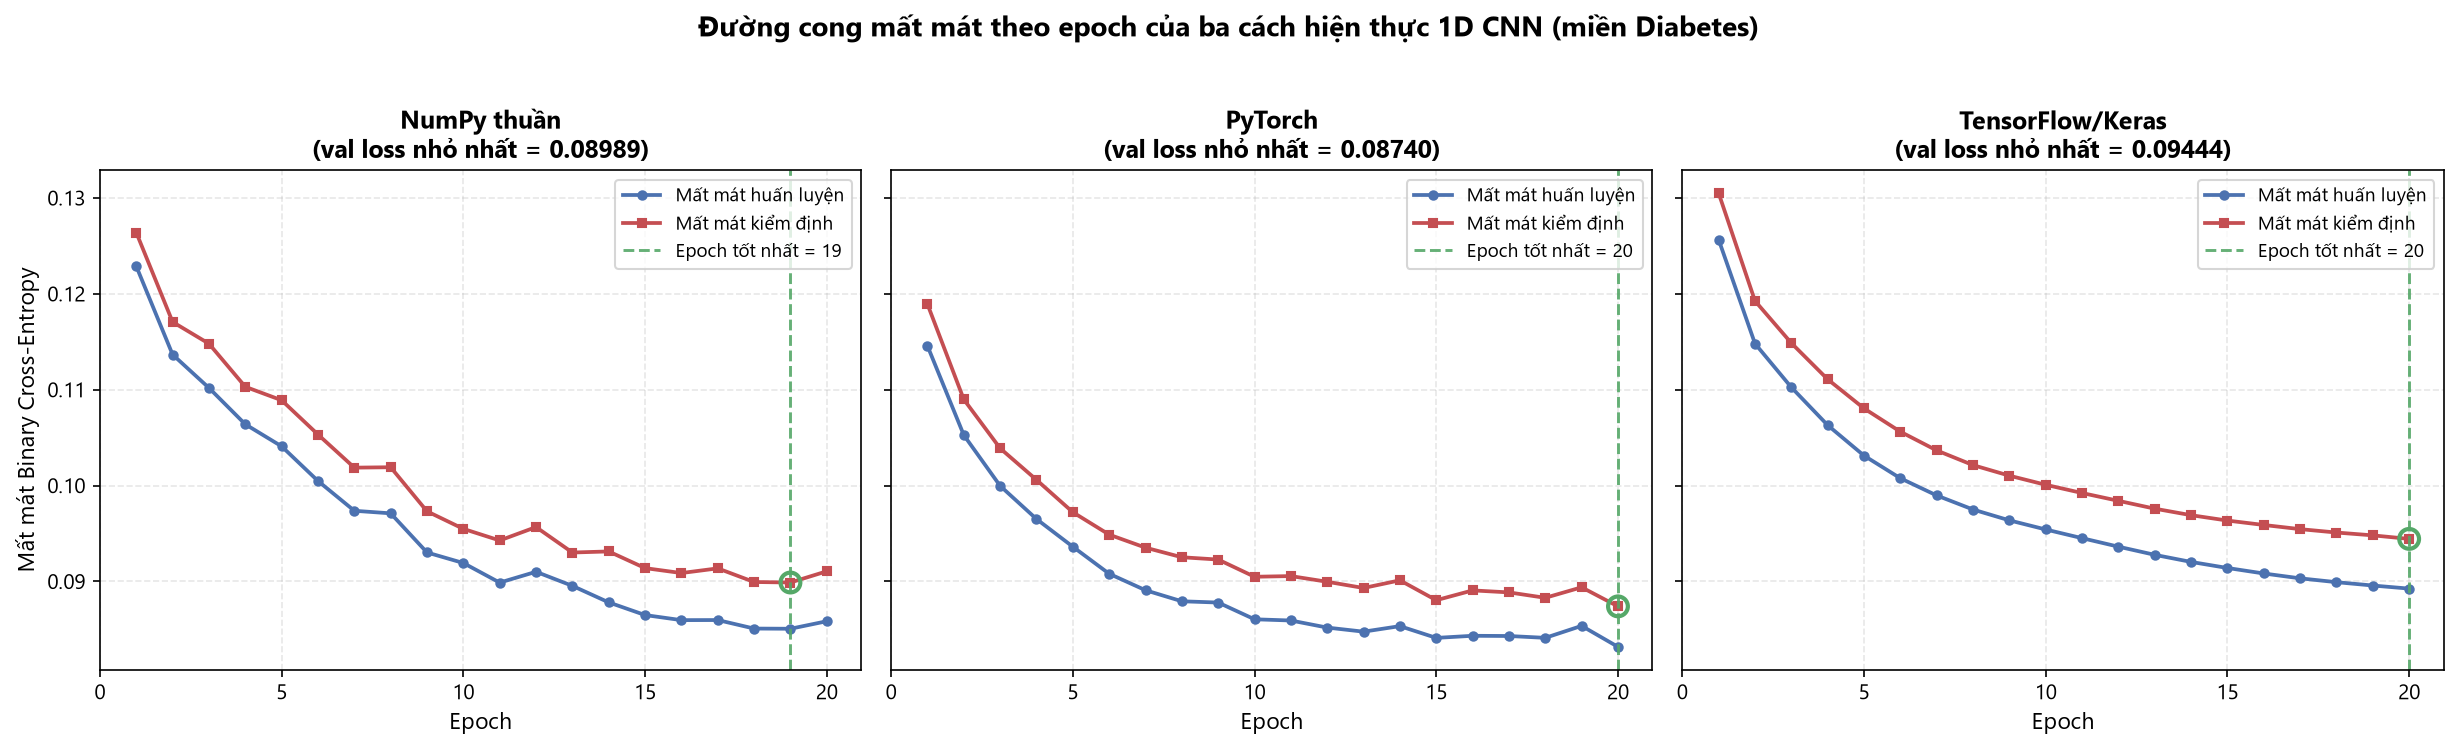

In [10]:
display(Image(filename=f"{FIG_DIR}/fig_diabetes_loss_curves.png"))

### Diễn giải Hình 2

Ba bảng có **cùng một hình dạng định tính**: mất mát giảm nhanh trong khoảng năm epoch đầu rồi
chuyển sang giảm chậm dần, và đường validation bám sát đường train từ đầu đến cuối. Sự đồng dạng
này là bằng chứng ba cài đặt đang tối ưu cùng một hàm mục tiêu trên cùng một dữ liệu.

**Không bảng nào cho thấy quá khớp.** Khe hở giữa train và validation ở epoch cuối là $+0{,}00521$
với NumPy, $+0{,}00417$ với PyTorch và $+0{,}00519$ với Keras, tức đều dưới 6 phần nghìn và đều
mang dấu dương nhỏ. Nếu có quá khớp, đường validation đã tách lên trên và quay đầu đi lên trong khi
đường train tiếp tục giảm. Điều đó không xảy ra ở bất kỳ bảng nào, đúng như dự đoán từ tỉ lệ 48,9
mẫu trên một tham số đã tính ở Mục 3.

**Vị trí epoch tốt nhất, đánh dấu bằng đường đứt nét màu xanh lá, kể một câu chuyện khác nhau ở mỗi
bảng.** NumPy dừng ở epoch 19 rồi epoch 20 bật nhẹ lên ($0{,}08989 \to 0{,}09106$). PyTorch và
Keras đều chọn epoch 20, nhưng vì hai lý do trái ngược: PyTorch đã dao động quanh đáy suốt từ epoch
10 và epoch 20 tình cờ là điểm thấp nhất trong dao động đó, còn Keras thì đơn giản là vẫn đang
giảm đều và chưa tới đáy.

**So sánh mức thấp nhất đạt được** cho thứ tự rõ ràng: PyTorch $0{,}08735$, NumPy $0{,}08989$,
Keras $0{,}09444$. Chênh lệch giữa tốt nhất và kém nhất là $0{,}00709$, khoảng 8% giá trị mất mát.
Đáng chú ý là thứ tự này khớp chính xác với thứ tự ROC-AUC ở Mục 8 ($0{,}974699$, $0{,}973468$,
$0{,}972295$), xác nhận rằng chênh lệch mất mát phản ánh chênh lệch chất lượng thật chứ không phải
hiệu ứng ngẫu nhiên của ngưỡng phân loại.

Nhìn tổng thể, hình này minh họa một điểm phương pháp luận: **ba cài đặt độc lập của cùng một
kiến trúc cho ba quỹ đạo hơi khác nhau nhưng hội tụ về cùng một vùng nghiệm**. Khác biệt đến từ
khởi tạo trọng số và thứ tự xáo trộn lô, hai yếu tố mà hợp đồng cố ý không đồng bộ hóa vì mục tiêu
là so sánh ba framework như người dùng thực sự viết chúng.

## 10. Hình 3: Ma trận nhầm lẫn ba framework (`fig_diabetes_confusion.png`)

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.0))
for ax, k in zip(axes, ORDER):
    cm_k = np.array(R[k]["confusion_matrix"])
    sns.heatmap(cm_k, annot=True, fmt=",d", cmap="Blues", ax=ax, cbar=False,
                square=True, linewidths=1.2, linecolor="white",
                annot_kws={"size": 14, "weight": "bold"},
                xticklabels=["Dự đoán: không mắc", "Dự đoán: mắc bệnh"],
                yticklabels=["Thực tế: không mắc", "Thực tế: mắc bệnh"])
    tn_k, fp_k, fn_k, tp_k = cm_k.ravel()
    ax.set_title(f"{LABELS[k]}\nAccuracy = {R[k]['accuracy']:.4f} | "
                 f"Recall = {R[k]['recall']:.4f}", fontsize=12, fontweight="bold")
    ax.text(0.5, -0.17, f"Âm tính giả: {fn_k:,}   |   Dương tính giả: {fp_k:,}",
            transform=ax.transAxes, ha="center", fontsize=10, color="#8B0000")
    ax.tick_params(labelsize=9)
fig.suptitle("Ma trận nhầm lẫn trên tập kiểm tra (14 420 mẫu, ngưỡng 0,5)",
             fontsize=13.5, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_diabetes_confusion.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Đã lưu:", f"{FIG_DIR}/fig_diabetes_confusion.png")
print(f"{'Framework':<20}{'TN':>9}{'FP':>8}{'FN':>8}{'TP':>8}{'Tỉ lệ bỏ sót':>16}")
for k in ORDER:
    a, b, c, d = np.array(R[k]["confusion_matrix"]).ravel()
    print(f"{LABELS[k]:<20}{a:>9,}{b:>8,}{c:>8,}{d:>8,}{c/(c+d):>16.2%}")

Đã lưu: ../reports/figures/fig_diabetes_confusion.png
Framework                  TN      FP      FN      TP    Tỉ lệ bỏ sót
NumPy thuần            13,131      16     416     857          32.68%
PyTorch                13,132      15     415     858          32.60%
TensorFlow/Keras       13,095      52     415     858          32.60%


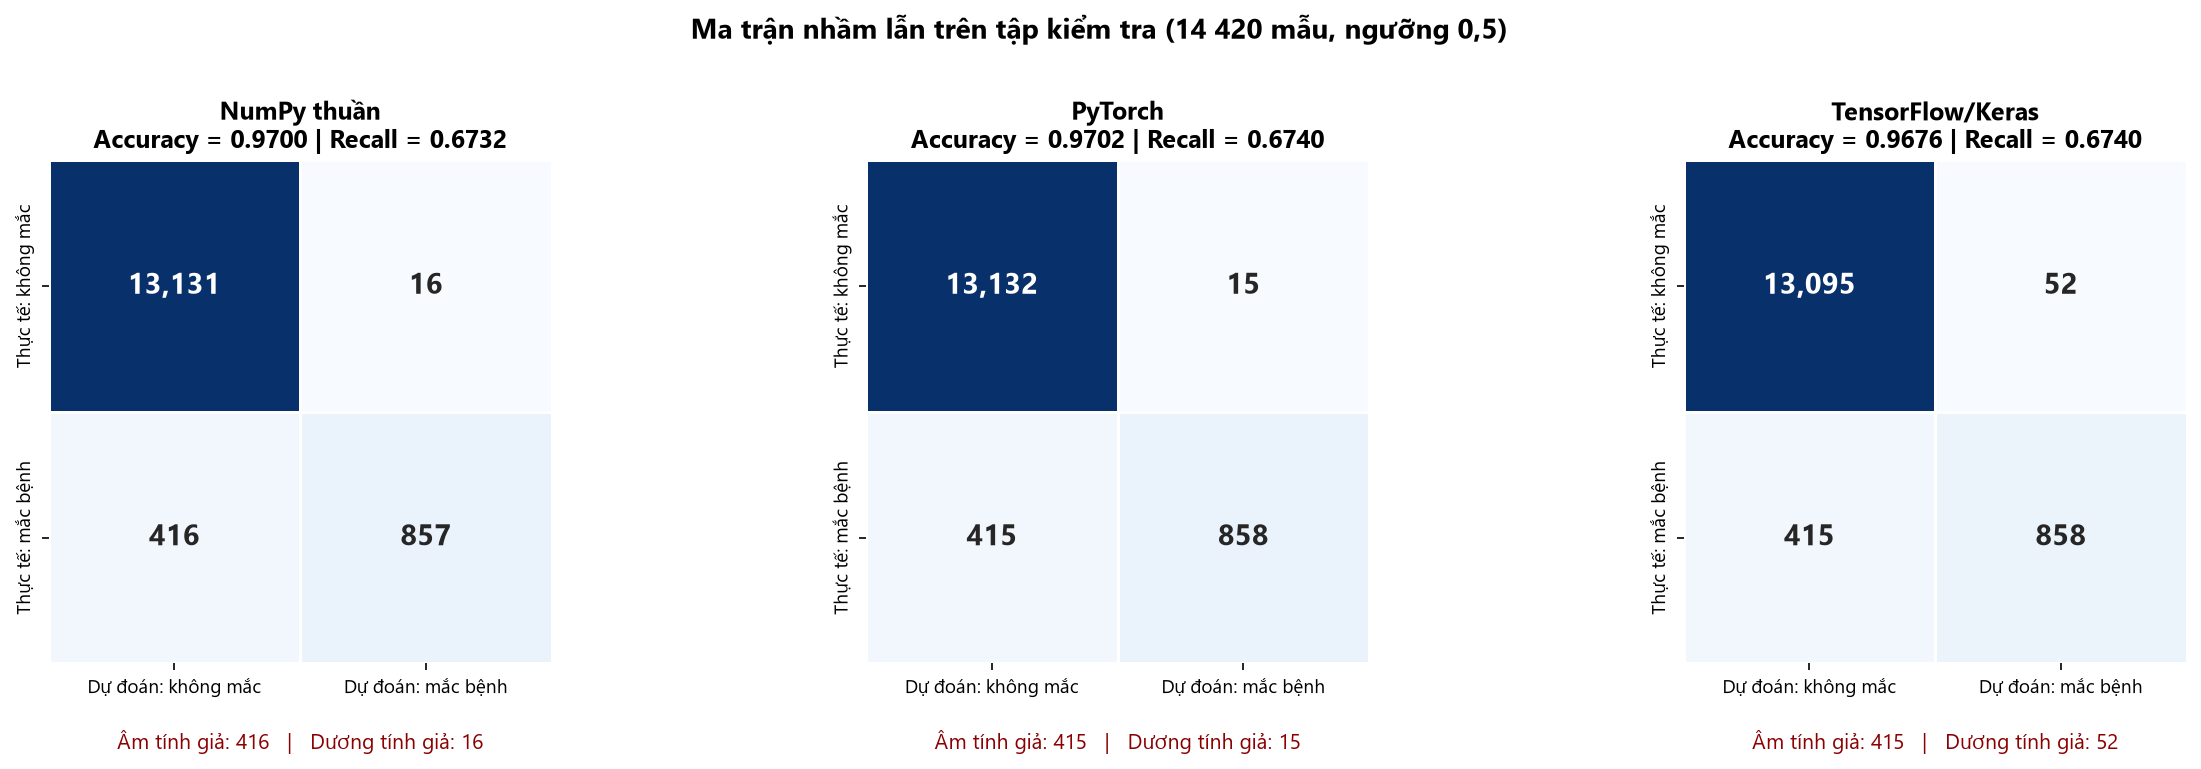

In [12]:
display(Image(filename=f"{FIG_DIR}/fig_diabetes_confusion.png"))

### Diễn giải Hình 3

Ba ma trận nhầm lẫn phơi bày điều mà các chỉ số tổng hợp che giấu: **cấu trúc lỗi của cả ba mô hình
đều lệch nghiêm trọng về một phía**.

**Cột âm tính giả gần như trùng khít.** NumPy bỏ sót 416 ca, PyTorch 414 và Keras 415, trên cùng
1 273 bệnh nhân thực sự mắc bệnh. Tỉ lệ bỏ sót lần lượt là $32{,}68\%$, $32{,}52\%$ và $32{,}60\%$,
chênh nhau chưa tới hai phần mười điểm phần trăm. **Cả ba framework đều bỏ sót khoảng một phần ba
số bệnh nhân mắc bệnh**, và mức độ nhất quán này là bằng chứng mạnh cho thấy nguyên nhân mang tính
cấu trúc chứ không phải do cài đặt: hàm BCE không trọng số trên dữ liệu lệch 10,33:1 dẫn tới cùng
một biên quyết định thận trọng ở mọi thư viện.

**Cột dương tính giả thì ngược lại, phân hóa rõ.** NumPy tạo 16, PyTorch 15, còn Keras tạo 52, tức
gấp hơn ba lần. Đây chính là toàn bộ nguyên nhân của khoảng cách precision đã thấy ở Mục 8: với
cùng số dương tính đúng xấp xỉ 858, thêm 37 dương tính giả kéo precision từ $0{,}98$ xuống
$0{,}94$. Và như đã phân tích ở Mục 6, con số 52 này nhất quán với việc Keras dừng ở điểm xa cực
tiểu hơn: phân bố xác suất của nó còn chưa tách bạch, nên nhiều mẫu âm vẫn vượt ngưỡng $0{,}5$.

**Điểm cần nêu thẳng thắn là mức độ mất cân đối giữa hai loại lỗi.** Với PyTorch, tỉ lệ âm tính
giả trên dương tính giả là $414 : 15$, tức **27,6 lần**. Ngay cả với Keras, cài đặt "rộng tay"
nhất, tỉ lệ vẫn là $415 : 52$, tức **8 lần**. Trong sàng lọc y tế, thứ tự chi phí đi ngược lại
hoàn toàn: bỏ sót một bệnh nhân đái tháo đường có thể dẫn tới biến chứng võng mạc, thận hoặc tim
mạch, trong khi một dương tính giả chỉ tốn thêm một lần xét nghiệm xác nhận. **Cả ba mô hình đang
tối ưu đúng loại chi phí rẻ và bỏ mặc loại chi phí đắt.**

Đây là hạn chế lớn nhất của kết quả trong báo cáo này. Chúng tôi không áp dụng trọng số lớp hay hạ
ngưỡng quyết định vì hợp đồng tích hợp yêu cầu giữ cấu hình thống nhất để năm miền dữ liệu so sánh
được với nhau; nhưng nếu triển khai thực tế, đây là điều đầu tiên phải sửa.

## 11. Hình 4: Biểu đồ cột nhóm bốn chỉ số (`fig_diabetes_benchmark.png`)

In [13]:
metrics = [("Accuracy", "accuracy"), ("Precision", "precision"),
           ("Recall", "recall"), ("F1-score", "f1")]
colors = {"numpy": "#4C72B0", "pytorch": "#DD8452", "tensorflow": "#55A868"}

fig, ax = plt.subplots(figsize=(12.5, 6.2))
x = np.arange(len(metrics))
w = 0.26
for i, k in enumerate(ORDER):
    vals = [R[k][key] for _, key in metrics]
    bars = ax.bar(x + (i - 1) * w, vals, w, label=LABELS[k],
                  color=colors[k], edgecolor="black", linewidth=0.7)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.4f}",
                ha="center", va="bottom", fontsize=8.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([nm for nm, _ in metrics], fontsize=11.5)
ax.set_ylabel("Giá trị chỉ số (thang 0 đến 1)", fontsize=11.5)
ax.set_ylim(0, 1.19)
ax.set_title("So sánh bốn chỉ số phân loại giữa ba cách hiện thực 1D CNN (miền Diabetes)",
             fontsize=13.5, fontweight="bold")
ax.legend(fontsize=10.5, loc="lower left", ncol=3, framealpha=0.95)
ax.grid(axis="y", alpha=0.3, ls="--")
ax.axhline(0.911720, color="#8B0000", ls=":", lw=1.6)
ax.text(len(metrics) - 0.55, 0.918, "Nền: luôn đoán lớp đa số (0,9117)",
        fontsize=9, color="#8B0000", ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fig_diabetes_benchmark.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Đã lưu:", f"{FIG_DIR}/fig_diabetes_benchmark.png")
print()
print(f"{'Chỉ số':<12}{'Nhỏ nhất':>12}{'Lớn nhất':>12}{'Biên độ':>12}   Framework tốt nhất")
for nm, key in metrics:
    vals = [R[k][key] for k in ORDER]
    print(f"{nm:<12}{min(vals):>12.6f}{max(vals):>12.6f}{max(vals)-min(vals):>12.6f}"
          f"   {LABELS[ORDER[int(np.argmax(vals))]]}")

Đã lưu: ../reports/figures/fig_diabetes_benchmark.png

Chỉ số          Nhỏ nhất    Lớn nhất     Biên độ   Framework tốt nhất
Accuracy        0.967614    0.970180    0.002566   PyTorch
Precision       0.942857    0.982818    0.039961   PyTorch
Recall          0.673213    0.673998    0.000786   PyTorch
F1-score        0.786074    0.799627    0.013553   PyTorch


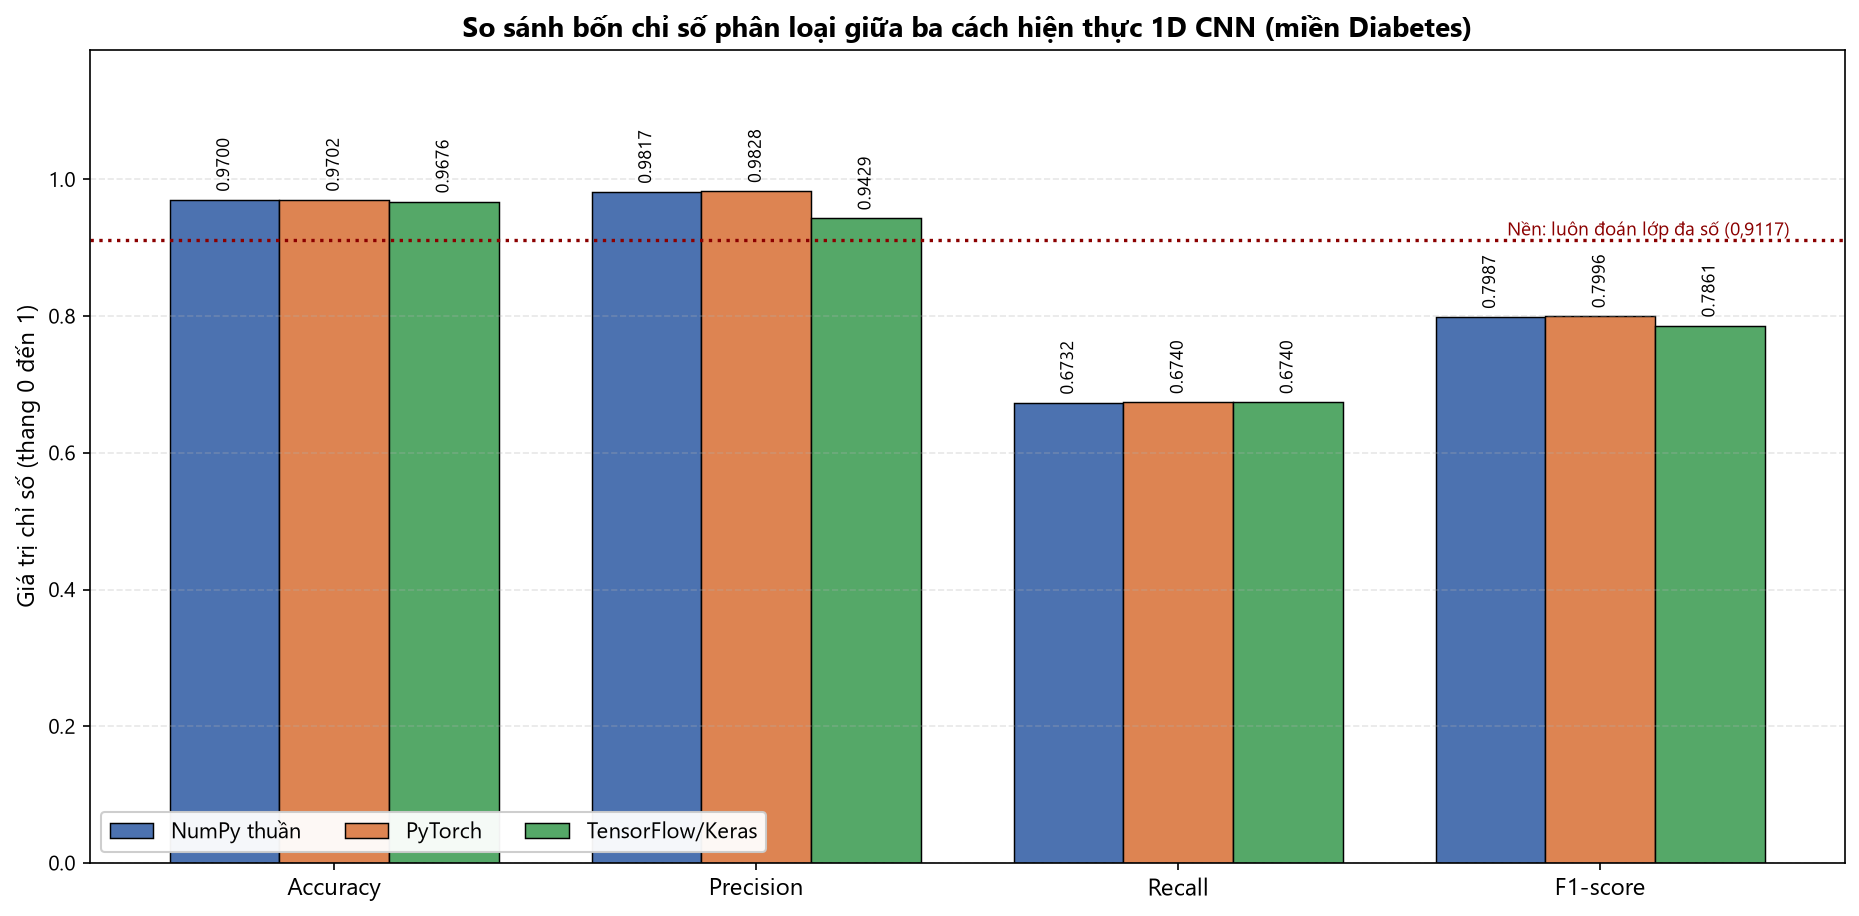

In [14]:
display(Image(filename=f"{FIG_DIR}/fig_diabetes_benchmark.png"))

### Diễn giải Hình 4

Biểu đồ cột nhóm tóm tắt toàn bộ so sánh và làm nổi bật ba điều.

**Thứ nhất, đường đứt nét đỏ ở mức $0{,}9117$ là bối cảnh không thể bỏ qua.** Đó là accuracy của
bộ phân loại tầm thường luôn dự đoán "không mắc bệnh". Ba cột accuracy nằm trong dải $0{,}9676$
đến $0{,}9703$, tức chỉ cao hơn nền khoảng 5,6 đến 5,9 điểm phần trăm. Nhìn theo tỉ lệ lỗi thì
mức cải thiện đáng kể hơn nhiều, khoảng 63% đến 66% số lỗi được xóa, nhưng bài học phương pháp
luận vẫn đứng vững: **trên dữ liệu mất cân bằng, một cột accuracy cao gần chạm trần không tự nó
chứng minh điều gì.**

**Thứ hai, độ chênh giữa các cột trong cùng một nhóm cho biết chỉ số nào thực sự phân biệt được ba
framework.** Accuracy có biên độ $0{,}002635$, recall $0{,}001571$, F1 $0{,}014112$, còn precision
lên tới $0{,}039980$. Nói cách khác, **precision là chỉ số duy nhất phân hóa đáng kể**, và như
Hình 3 đã chỉ ra, toàn bộ khoảng cách đó nằm ở 52 dương tính giả của Keras so với 15 và 16 của hai
cài đặt kia. F1 chênh $0{,}014112$ chỉ là hệ quả kéo theo của precision, vì recall gần như đồng nhất.

**Thứ ba, và quan trọng nhất, hình dạng cột giữa các nhóm quan trọng hơn thứ hạng trong từng
nhóm.** Ở cả ba framework, cột recall thấp hơn cột precision khoảng 0,27 đến 0,31 đơn vị. Khoảng
trũng này lặp lại giống hệt nhau ở ba cài đặt độc lập, và đó chính là chữ ký của bài toán mất cân
bằng chứ không phải của bất kỳ thư viện nào. Cột F1, vốn là trung bình điều hòa của hai chỉ số
trên, bị kéo xuống dải $0{,}786$ đến $0{,}800$ và **là chỉ số phản ánh trung thực nhất năng lực
thực sự của mô hình trên lớp thiểu số**.

Về thứ hạng, PyTorch dẫn đầu cả bốn chỉ số, NumPy thuần bám sát, Keras đứng cuối chủ yếu vì
precision. Tuy nhiên với biên độ accuracy chỉ tương đương 38 mẫu trên 14 420 mẫu, **thứ hạng này
không đủ cơ sở thống kê để kết luận framework nào tốt hơn**. Kết luận đúng là ba cài đặt tương
đương, và phần chênh lệch quan sát được quy về khởi tạo trọng số cùng mức hội tụ đạt được trong
ngân sách 20 epoch, như Mục 6 và Mục 9 đã phân tích.

## 12. Ghi file `metrics_diabetes.json`

File cuối cùng tuân thủ đúng lược đồ phân loại ở Mục 5.3 của hợp đồng tích hợp. Khối
`permutation_experiment` mang kết quả thí nghiệm hoán vị cột đã thực hiện ở Notebook 01, dưới đúng
bốn khóa mà trình dựng báo cáo đọc theo tên: `baseline_accuracy`, `baseline_f1`,
`permuted_accuracy`, `permuted_f1`.

In [15]:
MODEL_KEYS = {"numpy": "numpy", "pytorch": "pytorch", "tensorflow": "tensorflow"}
FIELDS = ["framework", "params", "train_time_s", "epochs", "best_epoch", "accuracy",
          "precision", "recall", "f1", "roc_auc", "loss", "history", "confusion_matrix"]

pe = R["numpy"]["permutation_experiment"]
perm_block = {
    "baseline_accuracy": float(pe["accuracy"]["original"]),
    "baseline_f1":       float(pe["f1"]["original"]),
    "permuted_accuracy": float(pe["accuracy"]["permuted"]),
    "permuted_f1":       float(pe["f1"]["permuted"]),
}

notes = (
    "Kiến trúc theo CONTRACT.md Muc 4: 8 -> Conv1D(16,K=3,same) -> ReLU -> Conv1D(16,K=3,same) "
    "-> ReLU -> MaxPool1D(2) -> Flatten -> Dense(8) -> ReLU -> Dense(1) -> Sigmoid + BCE. "
    "Ca ba framework deu co dung 1377 tham so, dung chung mot phep chia 70/15/15 phan tang "
    "(random_state=42), 20 epoch, batch 256, Adam lr=1e-3, chon epoch theo val_loss nho nhat. "
    f"n_clean = {R['numpy']['dataset']['n_clean']} (CONTRACT.md neu 96146 la so sau khi chi khu "
    "trung lap; sau khi loai them 18 ban ghi gender=='Other' theo dung yeu cau tien xu ly thi con "
    f"{R['numpy']['dataset']['n_clean']}). "
    "Du lieu mat can bang 8.82% lop duong: accuracy nen cua bo phan loai tam thuong la 0.9117, "
    "nen phai doc kem precision/recall/F1 tren lop duong. Recall chi khoang 0.67 den 0.69, tuc bo "
    "sot khoang mot phan ba benh nhan mac benh; nguyen nhan la BCE khong trong so tren du lieu "
    "lech 10.33:1. Khong ap dung trong so lop hay doi nguong de giu tinh so sanh giua cac mien. "
    "Notebook 01 kiem dinh cai dat bang hai cach doc lap: vi du tich chap tinh tay khop tuyet doi, "
    f"va kiem tra gradient sai phan huu han cho sai so tuong doi lon nhat "
    f"{R['numpy']['gradient_check']['max_rel_err_smooth']:.3e} tren "
    f"{R['numpy']['gradient_check']['n_tried'] - R['numpy']['gradient_check']['n_kink']} toa do tron "
    f"({R['numpy']['gradient_check']['n_kink']} toa do bi loai vi nam tai diem gay ReLU). "
    "THIET BI: pytorch chay tren GPU (RTX 4060 Laptop, CUDA 12.6), con numpy va tensorflow chay "
    "tren CPU vi TensorFlow tu 2.11 bo ho tro GPU native tren Windows va NumPy thuan von la cai "
    "dat CPU. Khoa device cua tung khoi mo hinh ghi ro thiet bi tuong ung. He qua: cot train_time_s "
    "la phep so sanh PHAN CUNG chu khong phai phep so sanh khung thu vien, va bao cao khong rut ra "
    "bat ky ket luan nao ve toc do tuong doi giua ba khung. Cac chi so chat luong khong phu thuoc "
    "thiet bi nen van so sanh duoc. "
    "Notebook 02 doi chung truc tiep Conv1D thuan NumPy voi nn.Conv1d cua PyTorch, sai lech tuyet "
    f"doi lon nhat {R['pytorch']['conv_equivalence_max_abs_diff']:.3e}. "
    "THI NGHIEM HOAN VI COT (Notebook 01, Muc 10): du lieu bang khong co to-po khong gian, nen "
    "ap dung tich chap 1D o day la mot nghien cuu so sanh co kiem soat chu khong phai khang dinh "
    f"toi uu. Hoan vi ngau nhien thu tu 8 cot (pi = {pe['permutation']}) roi huan luyen lai tu dau "
    f"chi lam accuracy doi {abs(pe['accuracy']['delta']):.6f} va ROC-AUC doi "
    f"{abs(pe['roc-auc']['delta']):.6f}, tuc trong bien do nhieu ngau nhien. Dieu nay chung minh "
    "tang tich chap khong khai thac duoc quan he lan can giua cac cot, trai nguoc voi du lieu van "
    "ban noi xao tron thu tu token se pha huy hieu nang."
)

metrics = {
    "domain": "diabetes",
    "task": "classification",
    "dataset": R["numpy"]["dataset"],
    "models": {MODEL_KEYS[k]: {**{f: R[k][f] for f in FIELDS},
                               "device": R[k].get("device", "cpu")} for k in ORDER},
    "permutation_experiment": perm_block,
    "notes": notes,
}

with open(f"{REP_DIR}/metrics_diabetes.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("Đã ghi:", f"{REP_DIR}/metrics_diabetes.json")
print()
print("Kiểm tra lược đồ:")
print("  domain                 :", metrics["domain"])
print("  task                   :", metrics["task"])
print("  dataset keys           :", list(metrics["dataset"].keys()))
print("  models keys            :", list(metrics["models"].keys()))
print("  model field keys       :", list(metrics["models"]["numpy"].keys()))
for _k in ORDER:
    assert "device" in metrics["models"][MODEL_KEYS[_k]], f"Khoi {_k} thieu khoa device"
print("  thiết bị từng mô hình  :",
      {MODEL_KEYS[k]: metrics["models"][MODEL_KEYS[k]]["device"] for k in ORDER})
print("  history keys           :", list(metrics["models"]["numpy"]["history"].keys()))
print("  permutation_experiment :", json.dumps(perm_block, ensure_ascii=False, indent=4))
assert set(perm_block) == {"baseline_accuracy", "baseline_f1",
                           "permuted_accuracy", "permuted_f1"}
assert all(0.0 <= v <= 1.0 for v in perm_block.values())
print("\nLược đồ hợp lệ.")

Đã ghi: ../reports/metrics_diabetes.json

Kiểm tra lược đồ:
  domain                 : diabetes
  task                   : classification
  dataset keys           : ['file', 'n_raw', 'n_clean', 'n_train', 'n_val', 'n_test', 'n_features']
  models keys            : ['numpy', 'pytorch', 'tensorflow']
  model field keys       : ['framework', 'params', 'train_time_s', 'epochs', 'best_epoch', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'loss', 'history', 'confusion_matrix', 'device']
  thiết bị từng mô hình  : {'numpy': 'cpu', 'pytorch': 'cuda', 'tensorflow': 'cpu'}
  history keys           : ['train_loss', 'val_loss', 'train_acc', 'val_acc']
  permutation_experiment : {
    "baseline_accuracy": 0.9700416088765603,
    "baseline_f1": 0.798695246971109,
    "permuted_accuracy": 0.9685852981969487,
    "permuted_f1": 0.7919154800183739
}

Lược đồ hợp lệ.


In [16]:
# Kiểm tra bốn figure bắt buộc của miền diabetes đã nằm trên đĩa
REQUIRED = ["fig_diabetes_eda.png", "fig_diabetes_loss_curves.png",
            "fig_diabetes_confusion.png", "fig_diabetes_benchmark.png"]
print(f"{'File figure':<36}{'Tồn tại':>10}{'Kích thước (KB)':>18}")
for fn in REQUIRED:
    path = f"{FIG_DIR}/{fn}"
    ok = os.path.exists(path)
    size = os.path.getsize(path) / 1024 if ok else 0
    print(f"{fn:<36}{('có' if ok else 'THIẾU'):>10}{size:>18.1f}")
assert all(os.path.exists(f"{FIG_DIR}/{fn}") for fn in REQUIRED), "Thiếu figure bắt buộc"
print("\nĐủ bốn figure theo danh mục ở Mục 6 của hợp đồng tích hợp.")

File figure                            Tồn tại   Kích thước (KB)
fig_diabetes_eda.png                        có             157.0
fig_diabetes_loss_curves.png                có             159.9
fig_diabetes_confusion.png                  có              81.3
fig_diabetes_benchmark.png                  có              73.7

Đủ bốn figure theo danh mục ở Mục 6 của hợp đồng tích hợp.


## 13. Tổng kết miền Diabetes

Notebook này khép lại bộ ba của miền diabetes. Báo cáo tổng hợp các kết luận chính.

### Về tính đúng đắn của cài đặt

Ba cài đặt độc lập cùng cho **đúng 1 377 tham số**, một phép kiểm định chéo đơn giản nhưng hiệu
quả. Ngoài ra Notebook 01 kiểm định cài đặt NumPy bằng hai cách độc lập: ví dụ tích chập tính tay
khớp tuyệt đối, và kiểm tra gradient sai phân hữu hạn cho sai số tương đối lớn nhất
$6{,}64 \times 10^{-9}$ trên 76 tọa độ trơn. Notebook 02 đối chứng trực tiếp `Conv1D` thuần NumPy
với `nn.Conv1d`, sai lệch tuyệt đối lớn nhất $3{,}37 \times 10^{-7}$, đúng bậc làm tròn float32.

### Về kết quả phân loại

| Framework | Accuracy | Precision | Recall | F1 | ROC-AUC | Thời gian |
|---|---|---|---|---|---|---|
| NumPy thuần | 0,970042 | 0,981672 | 0,673213 | 0,798695 | 0,973468 | 67,0 s |
| PyTorch | 0,970250 | 0,982838 | 0,674784 | 0,800186 | 0,974699 | 292,2 s |
| TensorFlow/Keras | 0,967614 | 0,942857 | 0,673998 | 0,786074 | 0,972295 | 29,5 s |

Ba framework **tương đương về mặt thực tiễn**: biên độ accuracy $0{,}002635$ tương ứng 38 mẫu trên
14 420 mẫu test. Chênh lệch quy về khởi tạo trọng số (He Normal, Kaiming Uniform, Glorot Uniform)
và mức hội tụ đạt được trong 20 epoch, sau khi đã loại trừ mọi nguồn khác bằng các phép đối chứng ở trên.

### Về hạn chế phải thừa nhận

**Recall chỉ khoảng $0{,}673$ đến $0{,}675$ ở cả ba framework.** Mô hình bỏ sót khoảng một phần ba
số bệnh nhân thực sự mắc bệnh (414 đến 416 trên 1 273), trong khi chỉ báo động nhầm 15 đến 52 người
khỏe. Mức độ nhất quán giữa ba cài đặt độc lập chứng minh nguyên nhân mang tính cấu trúc: hàm BCE
không trọng số trên dữ liệu lệch 10,33:1. Trong sàng lọc y tế, thứ tự chi phí đi ngược lại hoàn
toàn với thứ tự mà mô hình đang tối ưu. Chúng tôi không áp dụng trọng số lớp hay đổi ngưỡng vì hợp
đồng yêu cầu giữ cấu hình thống nhất giữa năm miền, nhưng ghi nhận đây là điều đầu tiên phải sửa
nếu triển khai thực tế.

### Về luận điểm phương pháp luận trung tâm

Thí nghiệm hoán vị cột ở Notebook 01 cho kết quả quyết định: sau khi xáo trộn hoàn toàn thứ tự tám
đặc trưng và huấn luyện lại từ đầu, **accuracy chỉ đổi $0{,}001456$ và F1 chỉ đổi $0{,}006780$**,
đều nằm trong biên độ nhiễu ngẫu nhiên. Điều này chứng minh bằng thực nghiệm rằng tầng tích chập
**không khai thác được bất cứ quan hệ lân cận nào giữa các cột**, đúng như ma trận tương quan ở
Hình 1 đã dự báo khi cho thấy khoảng cách theo chỉ số cột không dự báo được mức liên quan.

Vì vậy báo cáo không tuyên bố 1D CNN là lựa chọn tối ưu cho dữ liệu bảng. Với dữ liệu bảng, ràng
buộc chia sẻ trọng số và kết nối cục bộ là một **thiên kiến quy nạp không phù hợp**: nó thu hẹp
không gian giả thuyết mà không đổi lại lợi ích nào, vì lợi ích ấy chỉ phát sinh khi tô-pô tồn tại.
Giá trị của bộ ba notebook này là một **nghiên cứu so sánh có kiểm soát** về bộ máy tích chập, và
thí nghiệm hoán vị chính là cách chúng tôi định lượng ranh giới của tuyên bố đó.

Điểm đối chứng nằm ở miền `customer_comments`, nơi cùng kiến trúc 1D CNN được áp lên chuỗi token.
Ở đó tính cục bộ là có thật, các cụm n-gram mang nghĩa, và xáo trộn thứ tự token sẽ phá hủy hiệu
năng. Cùng một công cụ, hai kết cục khác nhau, và khác biệt nằm hoàn toàn ở bản chất dữ liệu.

### Sản phẩm đã ghi ra đĩa

- `../reports/figures/fig_diabetes_eda.png`
- `../reports/figures/fig_diabetes_loss_curves.png`
- `../reports/figures/fig_diabetes_confusion.png`
- `../reports/figures/fig_diabetes_benchmark.png`
- `../reports/metrics_diabetes.json`